In [45]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Rasulbek907\Desktop\LifeSpan_Peoples\Data\Feature_selection\Filtered_Features.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2022 entries, 0 to 2021
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          2022 non-null   int64  
 1   Unnamed: 0.2        2022 non-null   int64  
 2   name                2022 non-null   float64
 3   birth_date          2022 non-null   float64
 4   birth_place         2022 non-null   float64
 5   death_date          2022 non-null   float64
 6   death_place         2022 non-null   float64
 7   occupation          2022 non-null   float64
 8   awards              2022 non-null   float64
 9   alma_mater          2022 non-null   float64
 10  education           2022 non-null   float64
 11  spouse              2022 non-null   float64
 12  children            2022 non-null   float64
 13  occupation_cluster  2022 non-null   float64
 14  birth_year          2022 non-null   float64
 15  death_year          2022 non-null   float64
 16  life_s

=== Gradient Boosting Regression ===
R2: 0.8910590258051737
MSE: 637.0058578395402


C:\maya_temp\ipykernel_16744\3490447095.py:46: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


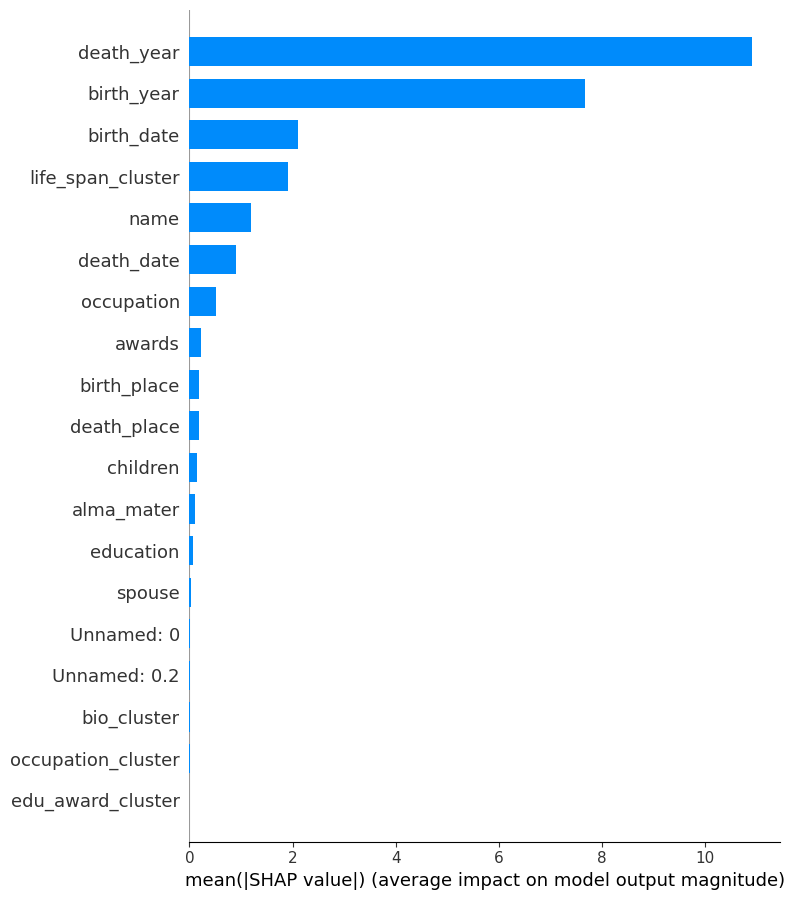

C:\maya_temp\ipykernel_16744\3490447095.py:62: RuntimeWarning: Mean of empty slice.
  privileged_mean = y_pred_bin[sensitive==1].mean()
c:\Users\Rasulbek907\Desktop\LifeSpan_Peoples\myvenv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\maya_temp\ipykernel_16744\3490447095.py:63: RuntimeWarning: Mean of empty slice.
  unprivileged_mean = y_pred_bin[sensitive==0].mean()


Demographic Parity Difference (before mitigation): nan

=== Weighted Regression (Bias Mitigation) ===
R2: 0.8910590258051737
MSE: 637.0058578395402
Demographic Parity Difference (after mitigation): nan


C:\maya_temp\ipykernel_16744\3490447095.py:62: RuntimeWarning: Mean of empty slice.
  privileged_mean = y_pred_bin[sensitive==1].mean()
c:\Users\Rasulbek907\Desktop\LifeSpan_Peoples\myvenv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\maya_temp\ipykernel_16744\3490447095.py:63: RuntimeWarning: Mean of empty slice.
  unprivileged_mean = y_pred_bin[sensitive==0].mean()
C:\maya_temp\ipykernel_16744\3490447095.py:94: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fair, X_test, plot_type="bar")


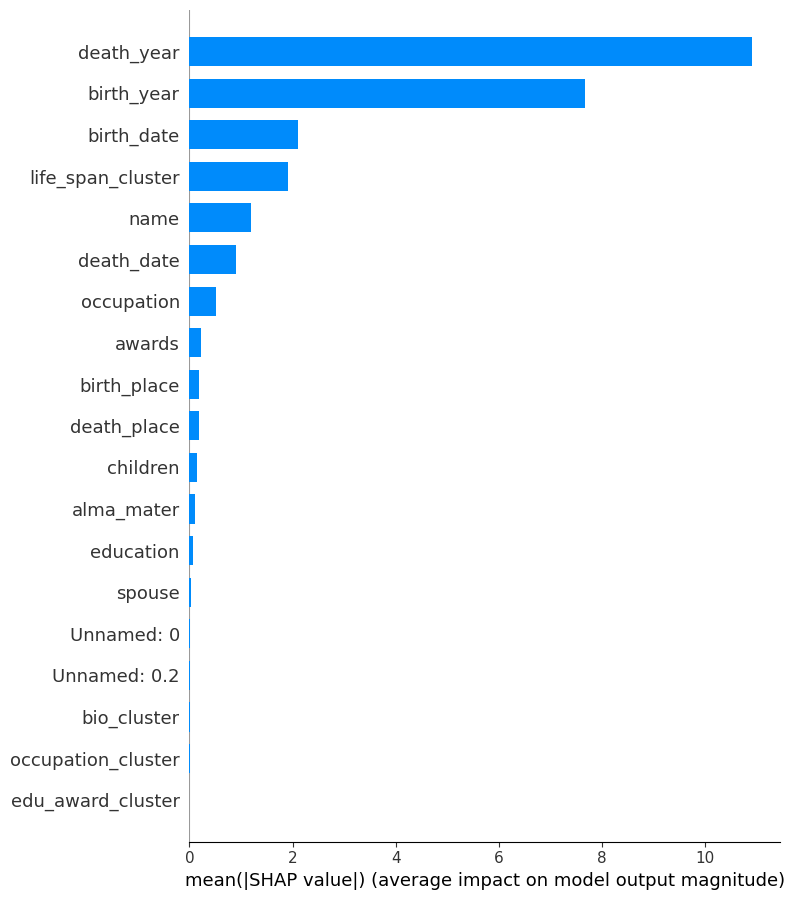

In [46]:
# ===============================
# 1️⃣ Kutubxonalarni import qilish
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import shap

# ===============================
# 2️⃣ Data tayyorlash
# ===============================
# df - sizning DataFrame, 'life_span' target, 'bio_cluster' sensitive
target = 'life_span'
sensitive_attr = 'bio_cluster'

X = df.drop(columns=[target])
y = df[target]
A = df[sensitive_attr]  # sensitive feature

# Train-test split
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.2, random_state=42
)

# ===============================
# 3️⃣ Gradient Boosting Regression
# ===============================
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

# Performance metrics
print("=== Gradient Boosting Regression ===")
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

# ===============================
# 4️⃣ SHAP explanations
# ===============================
explainer = shap.Explainer(gb, X_train)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Local explanation (birinchi sample)
shap.force_plot(explainer.expected_value, shap_values[0].values, X_test.iloc[0])

# ===============================
# 5️⃣ Fairness evaluation (Demographic Parity proxy)
# ===============================
# Continuous targetni binarize qilish
threshold = y_train.mean()
y_train_bin = (y_train > threshold).astype(int)
y_test_bin  = (y_test > threshold).astype(int)
y_pred_bin  = (y_pred > threshold).astype(int)

# Demographic Parity Difference
def demographic_parity_difference(y_true_bin, y_pred_bin, sensitive):
    privileged_mean = y_pred_bin[sensitive==1].mean()
    unprivileged_mean = y_pred_bin[sensitive==0].mean()
    return abs(privileged_mean - unprivileged_mean)

dp_diff = demographic_parity_difference(y_test_bin, y_pred_bin, A_test)
print("Demographic Parity Difference (before mitigation):", dp_diff)

# ===============================
# 6️⃣ Bias mitigation: Weighted Regression
# ===============================
# Sensitive group bo'yicha sample weight
weights = np.where(A_train==1, 0.5, 1.0)  # privileged / unprivileged

gb_weighted = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_weighted.fit(X_train, y_train, sample_weight=weights)
y_pred_fair = gb_weighted.predict(X_test)
y_pred_fair_bin = (y_pred_fair > threshold).astype(int)

# Performance
print("\n=== Weighted Regression (Bias Mitigation) ===")
print("R2:", r2_score(y_test, y_pred_fair))
print("MSE:", mean_squared_error(y_test, y_pred_fair))

# Fairness metric after mitigation
dp_diff_fair = demographic_parity_difference(y_test_bin, y_pred_fair_bin, A_test)
print("Demographic Parity Difference (after mitigation):", dp_diff_fair)

# ===============================
# 7️⃣ SHAP for weighted model (optional)
# ===============================
explainer_fair = shap.Explainer(gb_weighted, X_train)
shap_values_fair = explainer_fair(X_test)
shap.summary_plot(shap_values_fair, X_test, plot_type="bar")


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

In [47]:
threshold = y_train.mean()
y_train_bin = (y_train > threshold).astype(int)
y_test_bin  = (y_test > threshold).astype(int)
y_pred_bin  = (y_pred > threshold).astype(int)

def demographic_parity_difference(y_pred_bin, sensitive):
    privileged_mean = y_pred_bin[sensitive==1].mean()
    unprivileged_mean = y_pred_bin[sensitive==0].mean()
    return privileged_mean - unprivileged_mean

dp_diff = demographic_parity_difference(y_pred_bin, A_test)
print("Demographic Parity Difference:", dp_diff)


Demographic Parity Difference: nan


C:\maya_temp\ipykernel_16744\2851801903.py:7: RuntimeWarning: Mean of empty slice.
  privileged_mean = y_pred_bin[sensitive==1].mean()
c:\Users\Rasulbek907\Desktop\LifeSpan_Peoples\myvenv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\maya_temp\ipykernel_16744\2851801903.py:8: RuntimeWarning: Mean of empty slice.
  unprivileged_mean = y_pred_bin[sensitive==0].mean()


In [48]:
def equalized_odds_difference(y_true_bin, y_pred_bin, sensitive):
    privileged_TPR = ((y_pred_bin==1) & (y_true_bin==1) & (sensitive==1)).sum() / ((y_true_bin==1) & (sensitive==1)).sum()
    unprivileged_TPR = ((y_pred_bin==1) & (y_true_bin==1) & (sensitive==0)).sum() / ((y_true_bin==1) & (sensitive==0)).sum()
    return privileged_TPR - unprivileged_TPR

eo_diff = equalized_odds_difference(y_test_bin, y_pred_bin, A_test)
print("Equalized Odds Difference (proxy):", eo_diff)


Equalized Odds Difference (proxy): nan


C:\maya_temp\ipykernel_16744\1995741249.py:2: RuntimeWarning: invalid value encountered in scalar divide
  privileged_TPR = ((y_pred_bin==1) & (y_true_bin==1) & (sensitive==1)).sum() / ((y_true_bin==1) & (sensitive==1)).sum()
C:\maya_temp\ipykernel_16744\1995741249.py:3: RuntimeWarning: invalid value encountered in scalar divide
  unprivileged_TPR = ((y_pred_bin==1) & (y_true_bin==1) & (sensitive==0)).sum() / ((y_true_bin==1) & (sensitive==0)).sum()


In [49]:
y_pred_fair = gb_weighted.predict(X_test)
y_pred_fair_bin = (y_pred_fair > threshold).astype(int)

dp_diff_fair = demographic_parity_difference(y_pred_fair_bin, A_test)
eo_diff_fair = equalized_odds_difference(y_test_bin, y_pred_fair_bin, A_test)

print("Demographic Parity Difference (after mitigation):", dp_diff_fair)
print("Equalized Odds Difference (after mitigation):", eo_diff_fair)


Demographic Parity Difference (after mitigation): nan
Equalized Odds Difference (after mitigation): nan


C:\maya_temp\ipykernel_16744\2851801903.py:7: RuntimeWarning: Mean of empty slice.
  privileged_mean = y_pred_bin[sensitive==1].mean()
c:\Users\Rasulbek907\Desktop\LifeSpan_Peoples\myvenv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\maya_temp\ipykernel_16744\2851801903.py:8: RuntimeWarning: Mean of empty slice.
  unprivileged_mean = y_pred_bin[sensitive==0].mean()
C:\maya_temp\ipykernel_16744\1995741249.py:2: RuntimeWarning: invalid value encountered in scalar divide
  privileged_TPR = ((y_pred_bin==1) & (y_true_bin==1) & (sensitive==1)).sum() / ((y_true_bin==1) & (sensitive==1)).sum()
C:\maya_temp\ipykernel_16744\1995741249.py:3: RuntimeWarning: invalid value encountered in scalar divide
  unprivileged_TPR = ((y_pred_bin==1) & (y_true_bin==1) & (sensitive==0)).sum() / ((y_true_bin==1) & (sensitive==0)).sum()


# Solution 1 : Reweighting (Bias Mitigation)

In [24]:
train_gender = sf_train['gender'].values
weights = np.where(train_gender == 'F', 1.3, 1.0) 

In [25]:

model_rw = RandomForestClassifier(random_state=42)
model_rw.fit(X_train, y_train, sample_weight=weights)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
y_pred_rw = model_rw.predict(X_test)

In [27]:
dp_gender_rw = demographic_parity_difference(y_test, y_pred_rw, sensitive_features=sf_test['gender'])
eo_gender_rw = equalized_odds_difference(y_test, y_pred_rw, sensitive_features=sf_test['gender'])

print("\n=== After Reweighing (Gender) ===")
print(f"Demographic Parity Difference (Gender): {dp_gender_rw:.3f}")
print(f"Equalized Odds Difference (Gender): {eo_gender_rw:.3f}")


=== After Reweighing (Gender) ===
Demographic Parity Difference (Gender): 0.005
Equalized Odds Difference (Gender): 0.121


# Solution 2: ThresholdOptimizer(Bias Mitigation)

In [28]:
from fairlearn.postprocessing import ThresholdOptimizer

# Post-process predictions for fairness
post_processor = ThresholdOptimizer(
    estimator=model,
    constraints='demographic_parity',
    prefit=True
)

post_processor.fit(X_train, y_train, sensitive_features=sf_train['gender'])
fair_post_predictions = post_processor.predict(X_test, sensitive_features=sf_test['gender'])

print("Post-processed model fairness:")
print(f"Demographic Parity: {demographic_parity_difference(y_test, fair_post_predictions, sensitive_features=sf_test['gender']):.3f}")

Post-processed model fairness:
Demographic Parity: 0.101


In [29]:
print(f"Equalized Odds: {equalized_odds_difference(y_test, fair_post_predictions, sensitive_features=sf_test['gender']):.3f}")


Equalized Odds: 0.155


In [30]:
from fairlearn.postprocessing import ThresholdOptimizer

# Post-process predictions for fairness
post_processor = ThresholdOptimizer(
    estimator=model,
    constraints='demographic_parity',
    prefit=True
)

post_processor.fit(X_train, y_train, sensitive_features=sf_train['age_group'])
fair_post_predictions = post_processor.predict(X_test, sensitive_features=sf_test['age_group'])

print("Post-processed model fairness:")
print(f"Demographic Parity: {demographic_parity_difference(y_test, fair_post_predictions, sensitive_features=sf_test['age_group']):.3f}")

Post-processed model fairness:
Demographic Parity: 0.139


In [31]:
print(f"Equalized Odds: {equalized_odds_difference(y_test, fair_post_predictions, sensitive_features=sf_test['age_group']):.3f}")


Equalized Odds: 0.301
